### Importação das bibliotecas e carregamento do dataset

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df = pd.read_csv('E Commerce Dataset.csv')

# Análise exploratória dos dados

Visualização de uma amostra inicial do dataset

In [121]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


Visualização de informações sobre o dataset

In [122]:
# o número de linhas e colunas do dataset
print(df.shape, '\n')

# tipos de colunas e quantidade de valores não nulos
print(df.info(), '\n')

# sumário estatístico descritivo do dataset
print(df.describe(), '\n')

# quantidade de valores nulos em cada coluna
print(df.isna().sum(), '\n')

# quantos valores de cada tem na coluna target
print(df['Churn'].value_counts())

(5630, 20) 

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress 

In [123]:
df['Churn'].head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

Verifiquei os valores de algumas features que fiquei em dúvida na interpretação para ver quais eram categoricas (0,1) e quais eram numéricas para me ajudar a intepretalas corretamente

In [124]:
print(df['SatisfactionScore'].unique())
print(df['Complain'].unique())
print(df['HourSpendOnApp'].unique())
print(df['CouponUsed'].unique())

[2 3 5 4 1]
[1 0]
[ 3.  2. nan  1.  0.  4.  5.]
[ 1.  0.  4.  2.  9.  6. 11. nan  7. 12. 10.  5.  3. 13. 15.  8. 14. 16.]


# Visualização gráfica dos dados

Verifiquei o balanceamento do target utilizando um gráfico de contagem

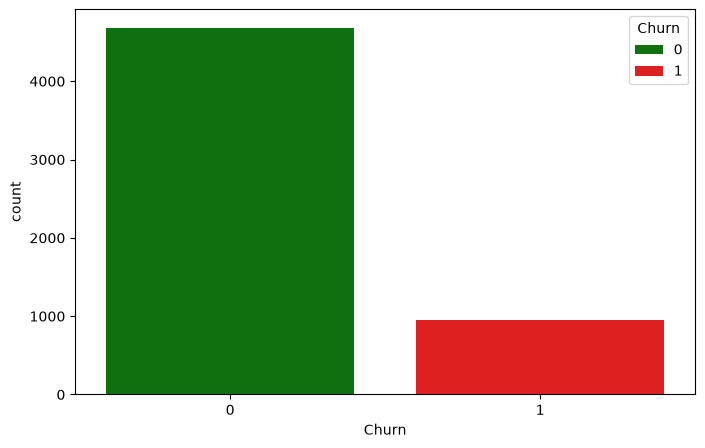

In [125]:
plt.figure(figsize=(8,5))
sns.countplot(df, x='Churn', hue='Churn', palette=['green', 'red'])
plt.show()

Verifiquei a média de cupons utilizados por cada grupo

Objetivo: Validar se o uso de cupons de desconto realmente ajuda a impedir do cliente cancelar o serviço

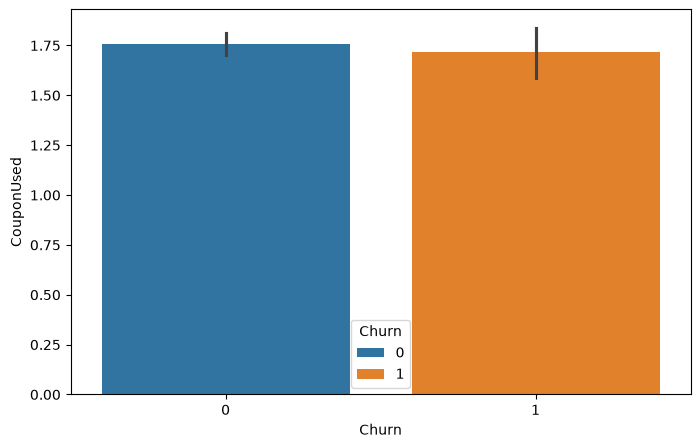

In [126]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Churn', y='CouponUsed', hue='Churn')
plt.show()

Verifiquei a distribuição das nivel de satisfação dos clientes

Objetivo: obter algum insight

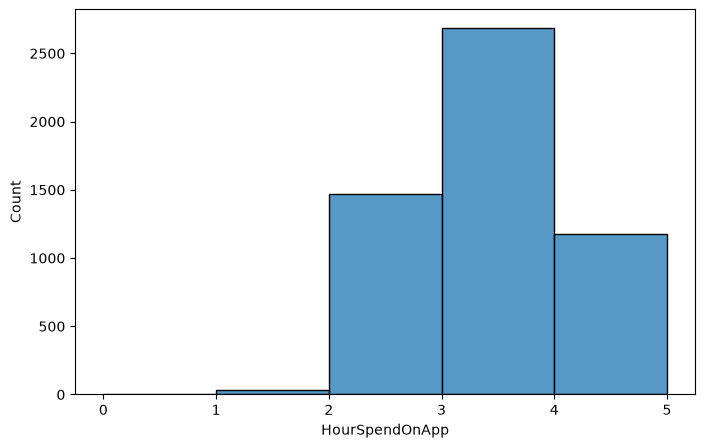

In [127]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='HourSpendOnApp', bins=5)
plt.show()

Verifiquei a distribuição da distancia do armazém até a casa dos clientes

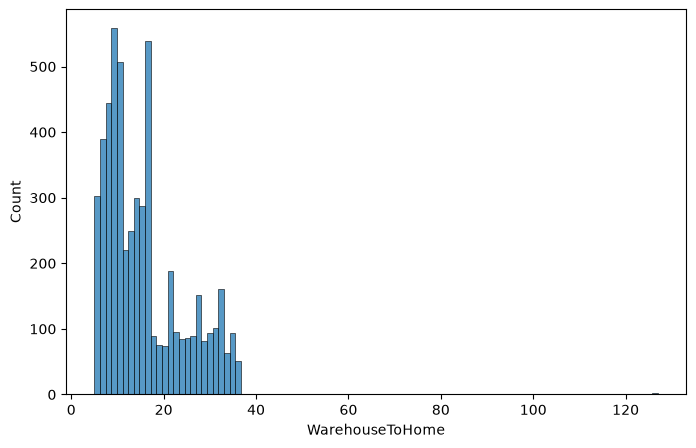

In [128]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='WarehouseToHome', bins=100)
plt.show()

No gráfico acima notei que havia um valor extremamente distante dos outros, então decidi plotar um gráfico de caixa para verificar se era um outlier

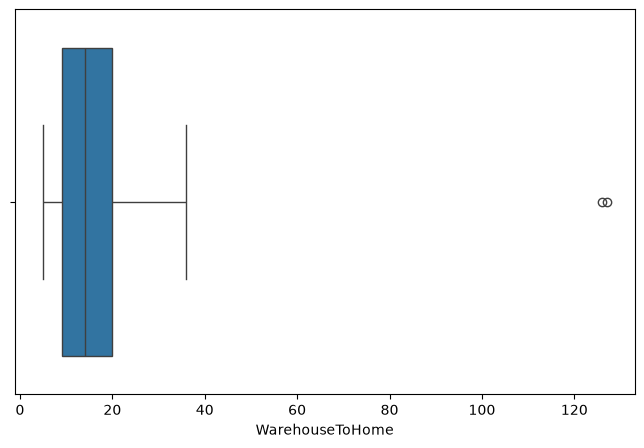

In [129]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='WarehouseToHome')
plt.show()

taxa de reclamações entre os grupos que cancelaram e não cancelaram o serviço

Objetivo: verificar se reclamações é um fator relevante para o cliente deixar de assinar o serviço

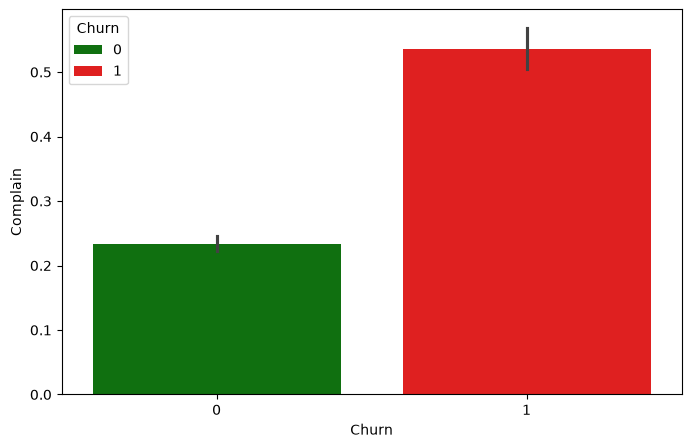

In [130]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='Complain', hue='Churn', palette=['green', 'red'])
plt.show()

nivel de satisfação entre os grupos

Objetivo: Verificar se o nível de satisfação é um fator relevante para o cancelamento do serviço

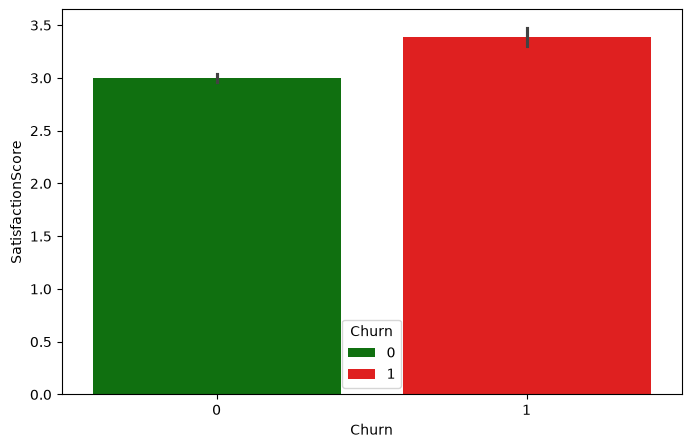

In [131]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='SatisfactionScore', hue='Churn', palette=['Green', 'Red'])
plt.show()

a distancia média entre o armazém e o cliente dos grupos que reclamaram e dos grupos que cancelaram o serviço

o objetivo desse gráfico foi testar minha hipótese de que os clientes que moram mais longe do armazem acabam tendo mais reclamações e por conta disso acabam deixando o serviço

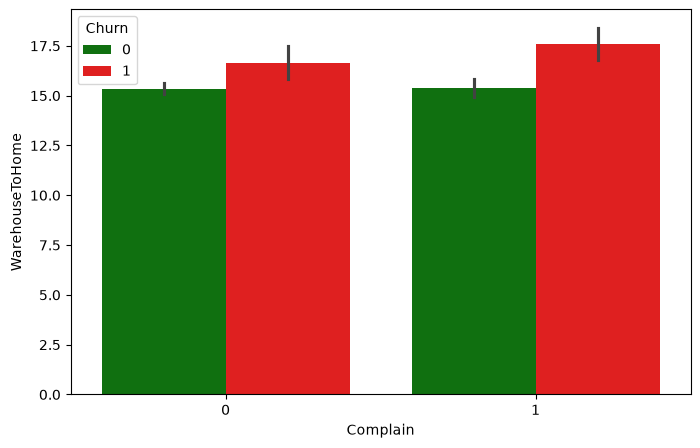

In [132]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Complain', y='WarehouseToHome', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verifiquei a quantidade média de pedidos entre os clientes que cancelaram ou não o serviço

Objetivo: testar minha hipótese de que os clientes que cancelaram o serviço foram os que mais compraram dentro da plataforma antes de cancelar o serviço

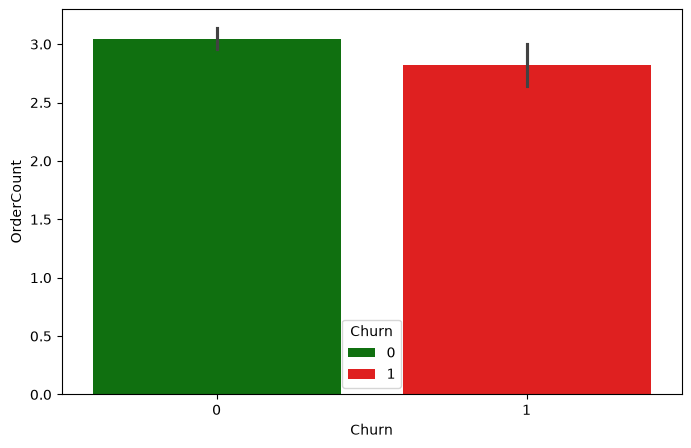

In [133]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='OrderCount', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verificar a correlação entre Distancia do cliente, quantidade de pedidos e o cancelamento do serviço

Objetivo: testar a hipótese de que existe a distância do cliente afeta a quantidade de pedidos que ele faz e consequentemente afeta a decisão dele de cancelar o serviço

[]

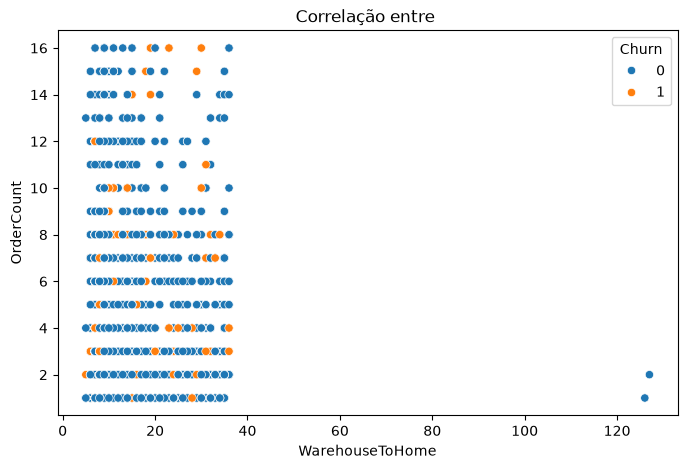

In [134]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='WarehouseToHome', y='OrderCount', hue='Churn')
plt.title('Correlação entre ')
plt.plot()

Fiz uma matriz de correlação das variaveis numéricas para verificar e validar as correlações reais das variaveis

Objetivo: Validar as correlações e não correlações que identifiquei nos gráficos anteriores e ver outras correlações que eu posso não ter percebido

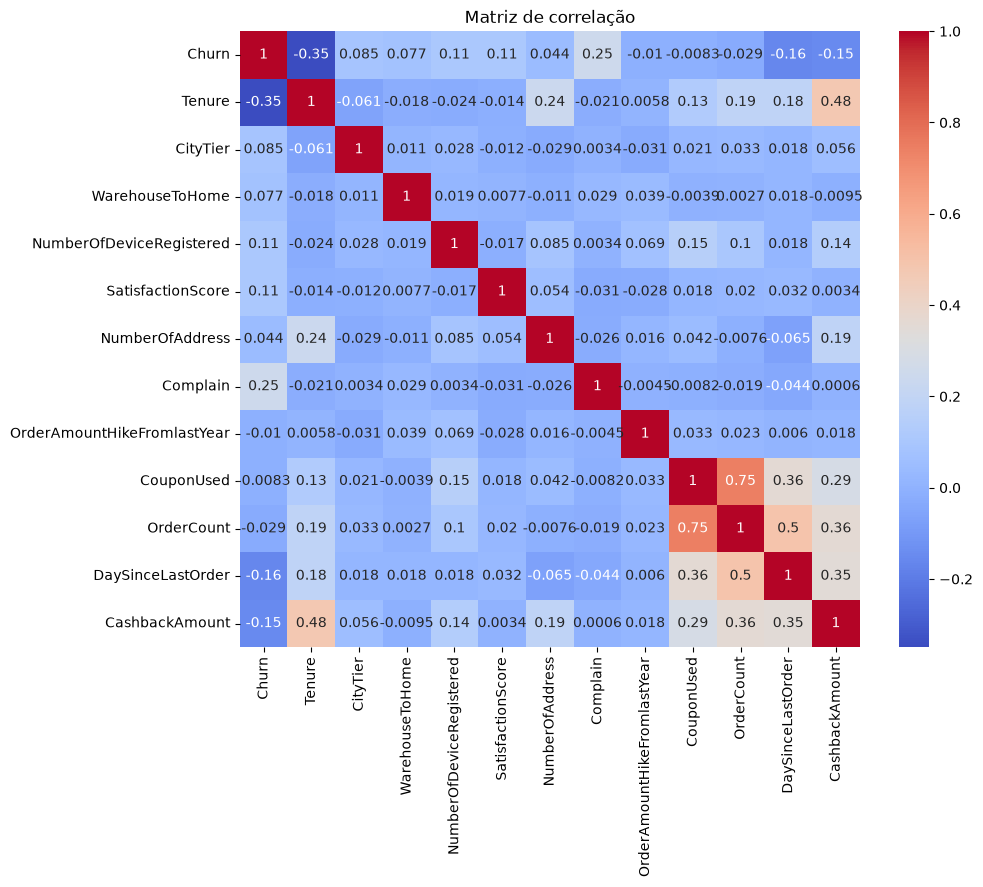

In [135]:
df_numeric = df[['Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
                'NumberOfDeviceRegistered', 'SatisfactionScore',
                'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']]

df_corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(data=df_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

### Insights

A base esta extremamente desbalanceada quanto ao target, a maior parte dos dados são de clientes que não cancelaram o serviço e isso é um problema pois o que precisamos prever são os clientes que vão cancelar o serviço, então vou precisar aplicar técnicas de balanceamento para o modelo ter 50/50 dos 2 casos.
Os cupons não são um fator relevante para retenção dos clientes, isso é importante pois talvez distribuir cupons de descontos não seja a melhor estratégia para reter clientes no serviço.
O maior fator que faz os clientes cancelarem o serviço são as reclamações, clientes que reclamam tem uma tendência muito maior, praticamente o dobro de chance de cancelarem o serviço do que os clientes que não tiveram nenhuma reclamação
e o maior fator para retenção do cliente é o tempo de permanência no serviço (Tenure) na empresa, e este fator é influenciado pela quantidade de cashback que também ifluência o churn como mostrado na matriz de correlação. Talvez utilizar o cashback seja uma estratégia melhor de retenção ao cliente do que cupons de desconto.

# Preparação dos dados (Data Prep)

### Exclui registros duplicados duplicados

In [136]:
# Remove a coluna ID do dataset para não afetar a detecção de duplicadas
df_duplicate = df.drop(columns=['CustomerID'])
df_duplicate.drop_duplicates()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.0,Computer,1,12.0,Credit Card,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,NaN,224
5624,0,1.0,Mobile Phone,3,12.0,UPI,Female,2.0,5,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,155
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186


### Checa o número de registros nulos de cada coluna

In [137]:
df_na = df_duplicate.copy()
df_na.isna().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

### Utiliza histograma e boxplot para identificar a distribuição dos valore nos campos

O Histograma foi utilizado para ter a visualização geral do padrão da distribuição, o boxplot foi utilizado identificar se nos campos haviam outliers que poderiam atrapalhar o calculo da média e para me auxiliar a identificar e confirmar o padrão geométrico identificado no diagrama

O Objetivo dessa etapa é auxiliar a decidir quais campos numéricos eu preencherei com média e mediana

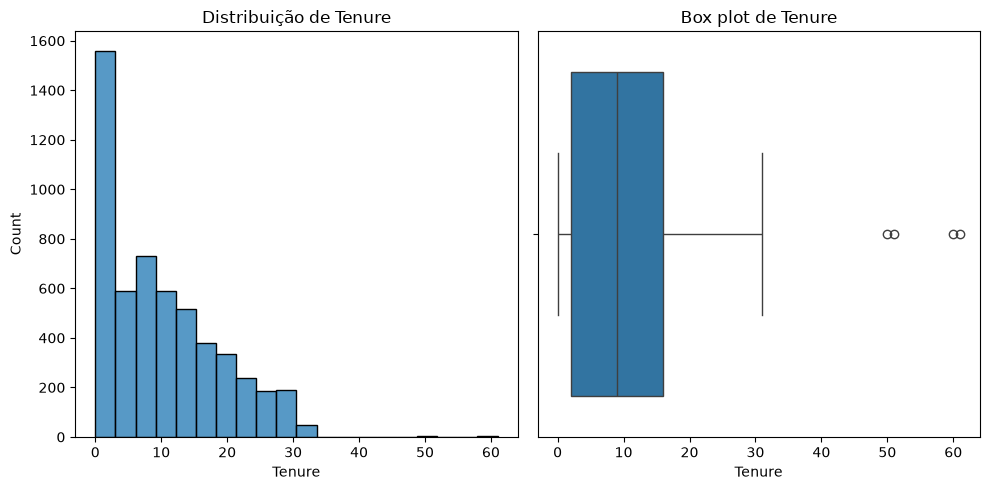

Tenure 
Média: 10.189899366380917 
Mediana: 9.0


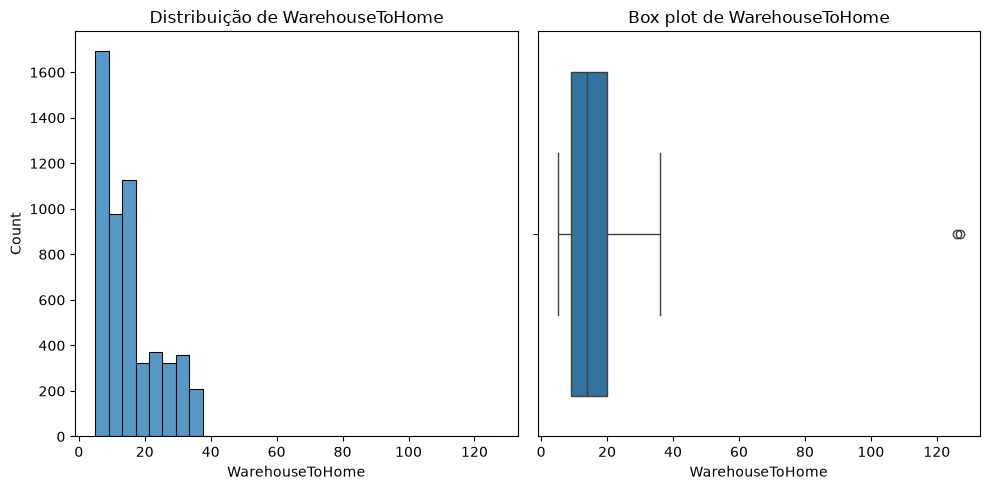

WarehouseToHome 
Média: 15.639895891429633 
Mediana: 14.0


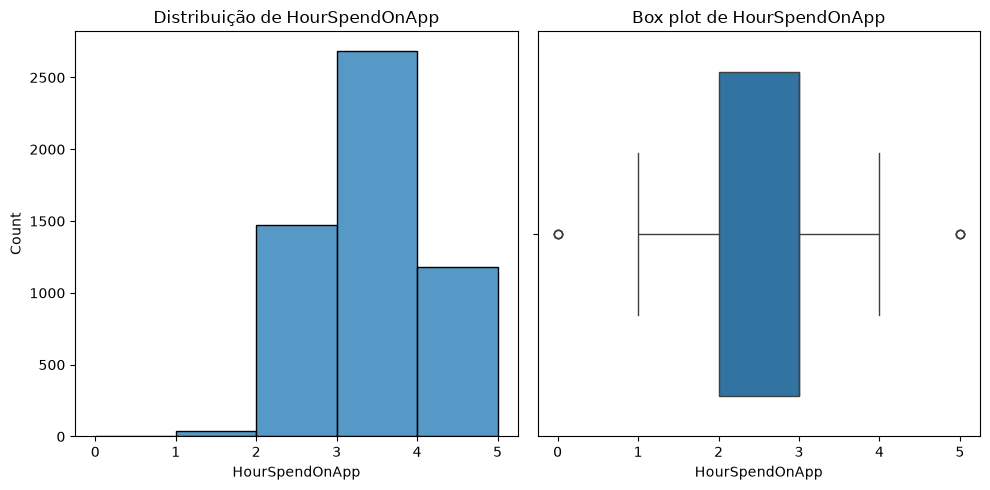

HourSpendOnApp 
Média: 2.9315348837209303 
Mediana: 3.0


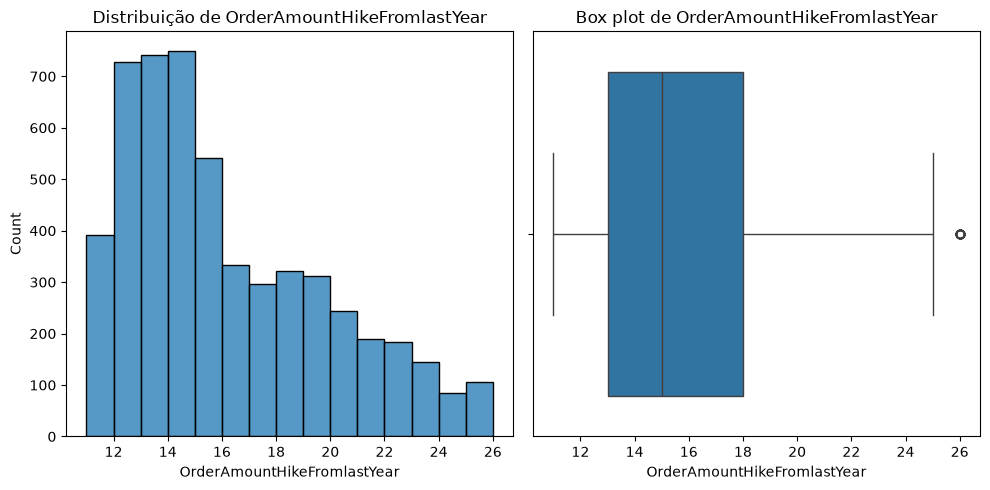

OrderAmountHikeFromlastYear 
Média: 15.707921714818266 
Mediana: 15.0


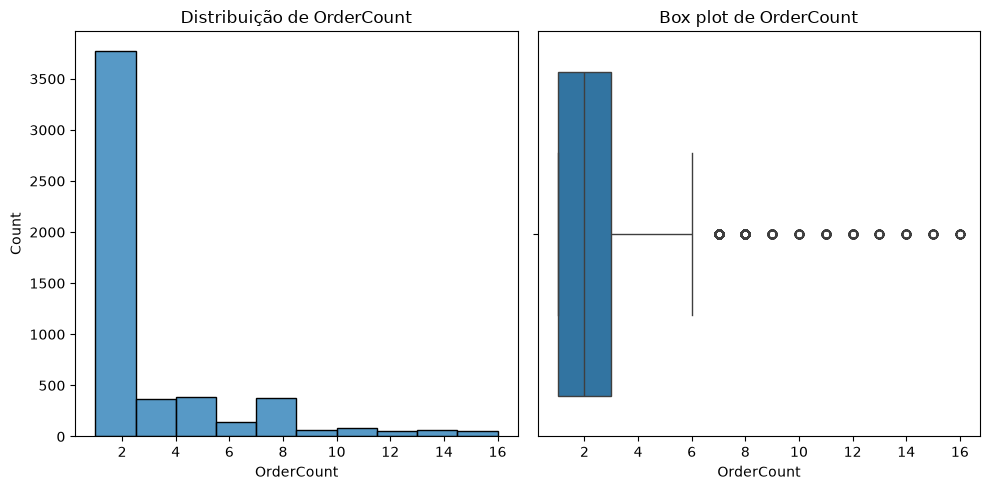

OrderCount 
Média: 3.0080044676098288 
Mediana: 2.0


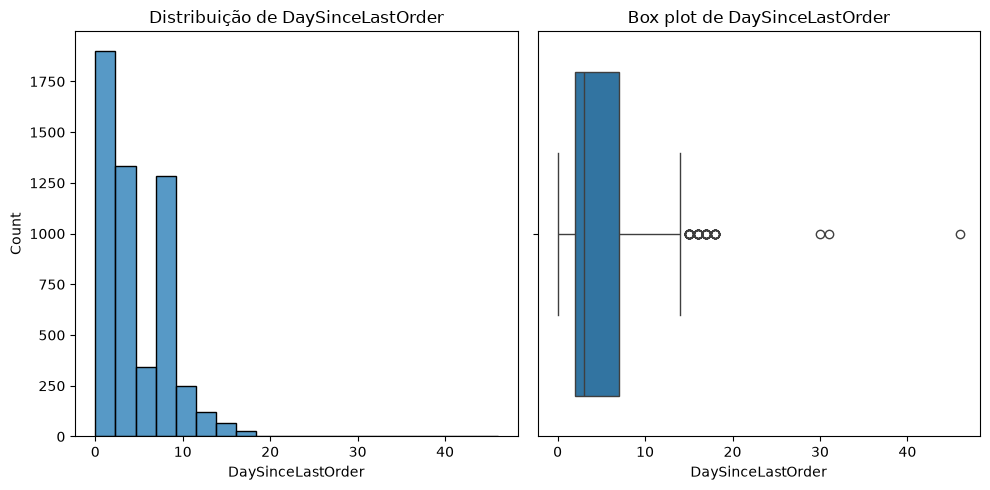

DaySinceLastOrder 
Média: 4.543490512868683 
Mediana: 3.0


In [138]:
columns_numeric = [('Tenure', 20), ('WarehouseToHome', 30), ('HourSpendOnApp', 5), ('OrderAmountHikeFromlastYear', 15),
                    ('OrderCount', 10), ('DaySinceLastOrder', 20)]

for c in columns_numeric:
    fig, axes = plt.subplots(1,2, figsize=(10,5))

    sns.histplot(data=df_na, x=c[0], bins=c[1], ax=axes[0])
    axes[0].set_title(f'Distribuição de {c[0]}')

    sns.boxplot(data=df_na, x=c[0], ax=axes[1])
    axes[1].set_title(f'Box plot de {c[0]}')

    plt.tight_layout()
    plt.show()

    print(f'{c[0]} \nMédia: {df[c[0]].mean()} \nMediana: {df[c[0]].median()}')

Após a geração dos gráficos eu decidi que iria preencher as seguintes colunas com mediana: Tenure, WarehouseToHome, OrderAmountHikeFromlastYear, OrderCount e DaySinceLastOrder, pois no histograma foi identificado uma distribuição assimétrica e no boxplot foi identificados outliers que destorceram a média

O campo que eu decidi preencher com a média foi o HourSpendOnApp, pois o histograma seguia uma distribuição simétrica e os outliers identificados no boxplot são valores coerentes e que não atrapalham o calculo da média

### Preenche os campos com média e mediana

In [139]:
columns_median = ['Tenure', 'WarehouseToHome', 'OrderAmountHikeFromlastYear', 'OrderCount', 'DaySinceLastOrder']

for c in columns_median:
    df_na[c] = df_na[c].fillna(df[c].median())

df_na['HourSpendOnApp'] = df_na['HourSpendOnApp'].fillna(df_na['HourSpendOnApp'].mean())

### Deleta registros nulos

As colunas que sobraram eram colunas categoricas que não fariam sentido preencher com média ou mediana, mas em um cenário real seria válido consultar o setor responsavel pela origem dos dados para tentar preencher o máximo de dados nulos

In [140]:
df_drop = df_na.copy()
df_drop = df_drop.dropna()

### Detecção de outliers

Foi gerado gráficos boxplot de todos as colunas numéricas para indentificar outliers.
Também foi gerado abaixo de cada gráfico um mini relatório contendo o nome do campo, limite inferior, limite superior, número de outliers e a porcentagem que a quantidade desses outliers representam no dataset inteiro

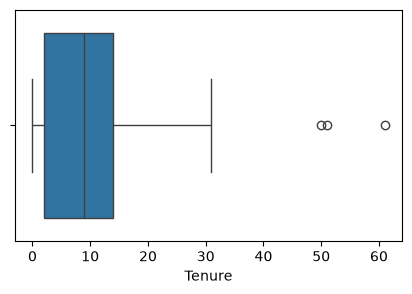

Tenure
Limite Inferior: 0
Limite Superior: 32.0
numero de ouliers: 3
Porcentagem de outliers: 0.06%


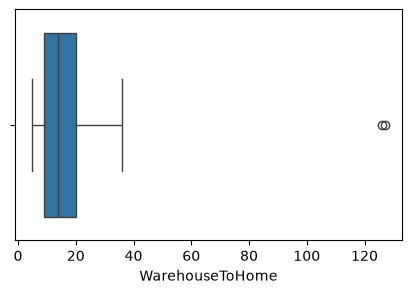

WarehouseToHome
Limite Inferior: 0
Limite Superior: 36.5
numero de ouliers: 2
Porcentagem de outliers: 0.04%


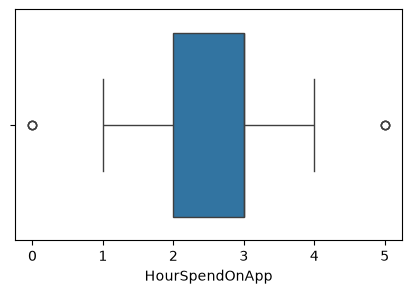

HourSpendOnApp
Limite Inferior: 0.5
Limite Superior: 4.5
numero de ouliers: 6
Porcentagem de outliers: 0.11%


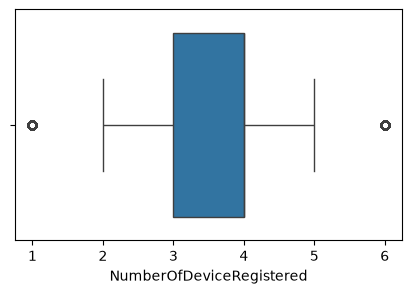

NumberOfDeviceRegistered
Limite Inferior: 1.5
Limite Superior: 5.5
numero de ouliers: 385
Porcentagem de outliers: 7.16%


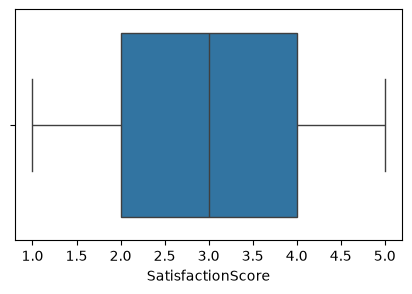

SatisfactionScore
Limite Inferior: 0
Limite Superior: 7.0
numero de ouliers: 0
Porcentagem de outliers: 0.00%


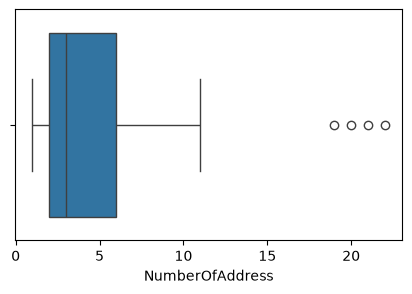

NumberOfAddress
Limite Inferior: 0
Limite Superior: 12.0
numero de ouliers: 4
Porcentagem de outliers: 0.07%


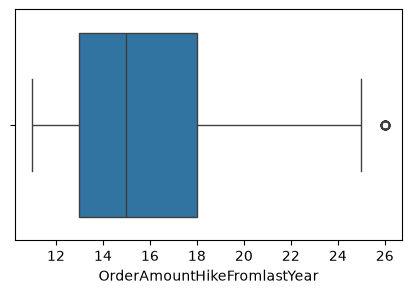

OrderAmountHikeFromlastYear
Limite Inferior: 5.5
Limite Superior: 25.5
numero de ouliers: 29
Porcentagem de outliers: 0.54%


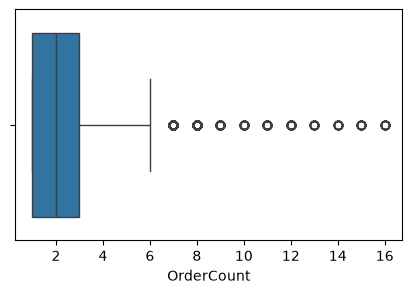

OrderCount
Limite Inferior: 0
Limite Superior: 6.0
numero de ouliers: 632
Porcentagem de outliers: 11.76%


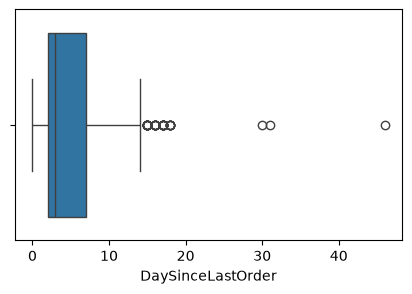

DaySinceLastOrder
Limite Inferior: 0
Limite Superior: 14.5
numero de ouliers: 45
Porcentagem de outliers: 0.84%


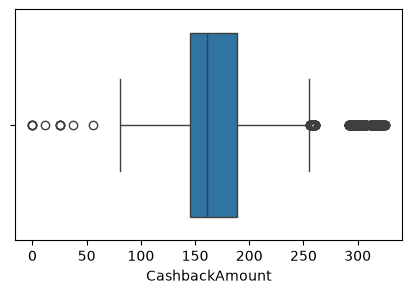

CashbackAmount
Limite Inferior: 79.0
Limite Superior: 255.0
numero de ouliers: 356
Porcentagem de outliers: 6.62%


In [141]:
df_outliers = df_drop.copy()

columns = df_outliers.columns
columns_numeric = columns.drop(['Churn','CityTier','PreferedOrderCat','PreferredLoginDevice','PreferredPaymentMode','Gender', 'MaritalStatus', 'Complain', 'CouponUsed'])

outliers_dict = {}

for c in columns_numeric:
    plt.figure(figsize=(5,3))
    sns.boxplot(data=df_outliers, x=c)
    plt.show()
    q1 = df_outliers[c].quantile(0.25)
    q3 = df_outliers[c].quantile(0.75)
    iqr = q3 - q1

    inferior_limit = max(0,q1 - 1.5 *  iqr)
    superior_limit = q3 + 1.5 * iqr

    outliers_dict[c] = {'inferior_limit': inferior_limit, 'superior_limit': superior_limit}

    df_outliers_only = df_outliers[(df_outliers[c] < inferior_limit) | (df_outliers[c] > superior_limit)]

    print(f'{c}\nLimite Inferior: {inferior_limit}\nLimite Superior: {superior_limit}')
    print(f'numero de ouliers: {len(df_outliers_only)}')
    print(f'Porcentagem de outliers: {(len(df_outliers_only) * 100 / len(df_outliers)):.2f}%')

O tratamento dos outiliers será feito pois 1 dos modelos que serão treinados neste projeto é o KNN. O KNN acaba sendo muito sensível a outliers afetando calculo da distância euclidiana do modelo. O outro modelo que será treinado é o Decision Tree, mas como ele é um modelo que não utiliza distancia euclidiana mas sim calculo de gini para sua decisões, outliers acabam sendo irrelevantes

Foi decidido que serão mantidos os outliers das colunas: HourSpendOnApp, NumberOfDeviceRegistered e OrderCount

Motivo: HourSpendOnApp e NumberOfDeviceRegistered foram mantidos pois são valores condizentes e próximas da maior concentração de dados, não afetando negativamente o calculo da distância euclidiana, já o OrderCount sera mantido pois os outliers representam aproximadamente 11% da base e estão muito distribuidos, também não distorcendo a distancia euclidiana.

Serão removidos completamente os outliers dos campos: Tenure, WarehouseToHome e NumberOfAddress

Motivo: esses outliers representam uma porcentagem muito pequena dos dados, chegando a menos de 1%, e eles estão muito distantes para ser realista substituir eles por um valor máximo.

Serão removidos parcialmete e substituidos por um valor máxima os campos DaySinceLastOrder CashbackAmount

explicação do que será feito: os outliers mais descrepantes serão completamente removidos, e os outliers mais próximos da concentração dos dados serão ajustados para um valor que sera o limite superior

motivo: Como a maior parte dos outliers do DaySinceLastOrder estão próximos da concentração dos dados é totalmente realista ajustar esses dados para o limite máximo, e os dados mais descrepantes iriam atrapalhar muito a distância euclidiana então serão removidos. No  caso do CashbackAmount os outiliers representavam aproximadamente 6% dos dados da base, então para tentar diminuir a perda dos dados eu fiz uma análise (na celula abaixo) para identificar em quanto eu poderia diminuir esta perda apenas excluindo os outiliers mais descrepantes, e o resultado uma perda de aproximadamente 5%, para os outliers mais próximos da concentração foram substituidos os valores para o limite superior

A coluna SatisfactionScore não houveram outliers, muito provavelmente por ser um coluna mais restrita (1-5)

Quantos registros serão perdidos excluindo apenas os outliers mais descrepantes da coluna CashbackAmount

In [142]:
outliers_to_drop_count = df_outliers.loc[df_outliers['CashbackAmount'] > 265, 'CashbackAmount'].count()
print(f'Numero de outliers: {outliers_to_drop_count}')
print(f'Porcentagem de outliers: {outliers_to_drop_count * 100 / len(df_outliers):.2f}%')

Numero de outliers: 283
Porcentagem de outliers: 5.27%


Remoção completa dos outliers das colunas Tenure, WarehouseToHome e NumberOfAddress

In [143]:
columns_outliers_drop_completely = ['Tenure', 'WarehouseToHome', 'NumberOfAddress']
columns_outliers_drop_adjust_partially = ['DaySinceLastOrder', 'CashbackAmount']

for c in columns_outliers_drop_completely:
    df_outliers = df_outliers[~(df_outliers[c] > outliers_dict[c]['superior_limit'])]

Remoção parcial das colunas DaySinceLastOrder e CashbackAmount

In [144]:
df_outliers = df_outliers[~(df_outliers['DaySinceLastOrder'] > 20)]
df_outliers = df_outliers[~(df_outliers['CashbackAmount'] > 265)]

Substituição dos outliers restantes pelo limite superior calculado anteriormente

In [145]:
superior_limit_days = outliers_dict['DaySinceLastOrder']['superior_limit']
superior_limit_cashback = outliers_dict['CashbackAmount']['superior_limit']

df_outliers.loc[df_outliers['DaySinceLastOrder'] > superior_limit_days, 'DaySinceLastOrder'] = superior_limit_days
df_outliers.loc[df_outliers['CashbackAmount'] > superior_limit_cashback, 'CashbackAmount'] = superior_limit_cashback